<a href="https://colab.research.google.com/github/MaggieHDez/ClassFiles/blob/main/proyecto_final_255879.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install keras-tcn gradio plotly scikit-learn xgboost -q

In [3]:
import tensorflow as tf

print("GPUs disponibles:", tf.config.list_physical_devices('GPU'))

GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Proyecto Final - Pronóstico de Demanda Eléctrica
>**Clase:** Métodos para pronóstico y analítica avanzada\
>**Alumno:** Margarita Cristina Hernández Delgadillo\
>**Matrícula:** 255879\
>**Fecha:** 22 de Mayo de 2026

## 1. Análisis Exploratorio de Datos (EDA)

In [4]:
# =========================================================
# 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import gaussian_kde
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf

import warnings
warnings.filterwarnings("ignore")


# =========================================================
# 1.1 CARGA DEL DATASET
# =========================================================

# Cambia el nombre del archivo por el que estés usando
df = pd.read_csv("/content/drive/MyDrive/ClassFiles/Metodos_de_Pronostico/datos_modelo.csv")

print("Primeras filas del dataset:")
print(df.head())

print("\nColumnas disponibles:")
print(df.columns.tolist())

# =========================================================
# 1.2 DEFINIR COLUMNA DE FECHA Y VARIABLE OBJETIVO
# =========================================================

# Cambia estos nombres según tu archivo
fecha_col = "timestamp"
target_col = "active_power_mw"

df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")
df[target_col] = pd.to_numeric(df[target_col], errors="coerce")

df = df.sort_values(fecha_col).reset_index(drop=True)

print("Rango de fechas:")
print("Inicio:", df[fecha_col].min())
print("Fin:", df[fecha_col].max())

print("\nNúmero de registros:", len(df))

# =========================================================
# 1.3 INFORMACIÓN GENERAL DEL DATASET
# =========================================================

print("=== INFORMACIÓN GENERAL ===")
print(df.info())

print("\n=== ESTADÍSTICA DESCRIPTIVA ===")
print(df.describe())

print("\nDimensiones del dataset:")
print(df.shape)

print("\n=== VALORES FALTANTES ===")
faltantes = df.isna().sum()
print(faltantes)
total_faltantes = faltantes.sum()

print("\n=== PORCENTAJE DE VALORES FALTANTES ===")
faltantes_pct = (df.isna().sum() / len(df)) * 100
print(faltantes_pct)

print("\nDuplicados totales:", df.duplicated().sum())
print("Duplicados por fecha:", df.duplicated(subset=[fecha_col]).sum())

Primeras filas del dataset:
     timestamp  active_power_mw  apparent_temperature_c  cloud_cover_percent  \
0  2/1/21 1:00      1508.726498               22.100000            21.766667   
1  2/1/21 2:00      1474.224972               21.803333            26.833333   
2  2/1/21 3:00      1448.436605               21.633333            22.300000   
3  2/1/21 4:00      1426.507838               21.223333            25.766667   
4  2/1/21 5:00      1419.126334               21.003333            17.533333   

   month  hour  is_holiday  is_weekend  is_school_vacation  \
0      1     1           0           1                   0   
1      1     2           0           1                   0   
2      1     3           0           1                   0   
3      1     4           0           1                   0   
4      1     5           0           1                   0   

   active_power_lag_1h  ...  active_power_lag_15h  active_power_lag_16h  \
0          1569.519607  ...           1482.

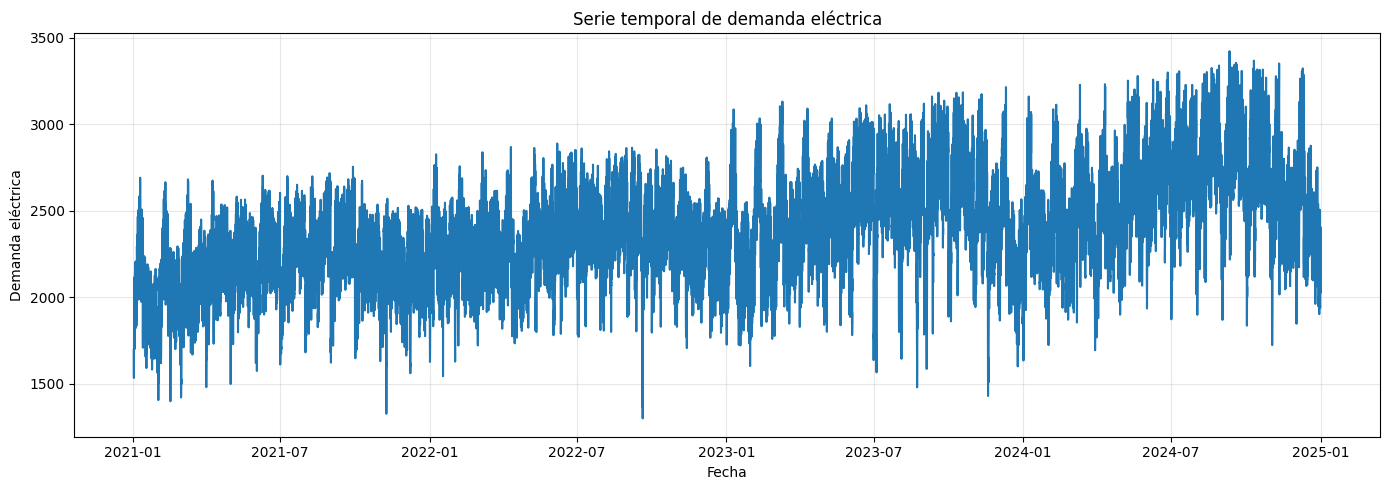

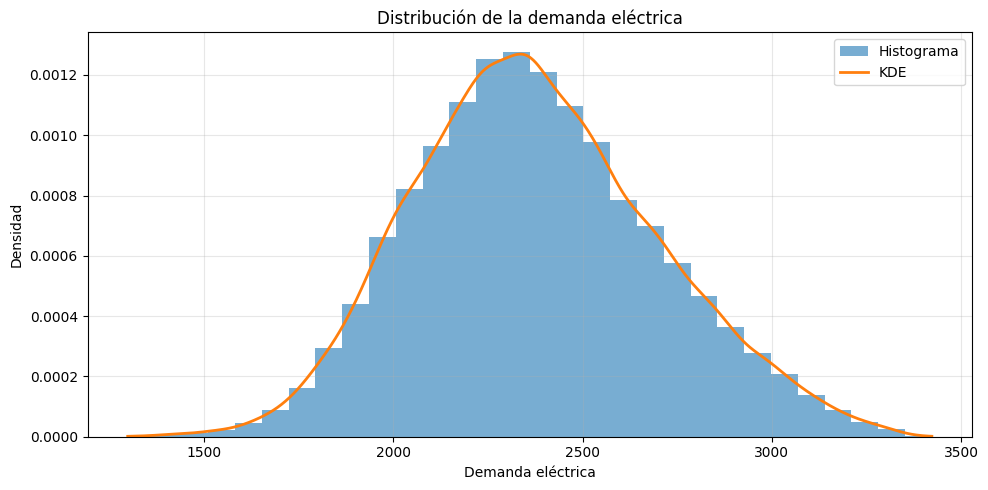

=== DETECCIÓN DE VALORES ATÍPICOS ===
Q1: 2148.90977998342
Q3: 2584.644313
IQR: 435.7345330165799
Límite inferior: 1495.30798045855
Límite superior: 3238.2461125248697
Cantidad de valores atípicos: 181
Porcentaje de valores atípicos: 0.52 %


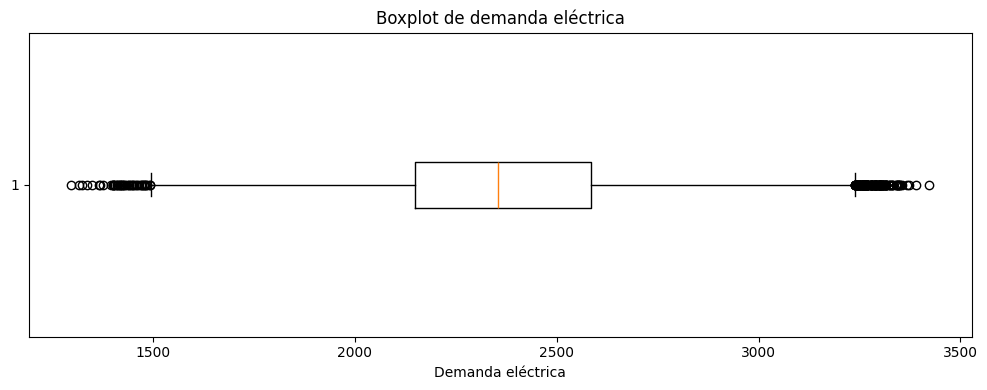

,timestamp,active_power_mw,apparent_temperature_c,cloud_cover_percent,month,hour,is_holiday,is_weekend,is_school_vacation,active_power_lag_1h,...,active_power_lag_15h,active_power_lag_16h,active_power_lag_17h,active_power_lag_18h,active_power_lag_19h,active_power_lag_20h,active_power_lag_21h,active_power_lag_22h,active_power_lag_23h,active_power_lag_24h
721,2021-02-01 02:00:00,1474.224972,21.803333,26.833333,1,2,0,1,0,1508.726498,...,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638,1674.169500
722,2021-02-01 03:00:00,1448.436605,21.633333,22.300000,1,3,0,1,0,1474.224972,...,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549,1629.903638
723,2021-02-01 04:00:00,1426.507838,21.223333,25.766667,1,4,0,1,0,1448.436605,...,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065,1575.752549
724,2021-02-01 05:00:00,1419.126334,21.003333,17.533333,1,5,0,1,0,1426.507838,...,1466.621504,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961,1540.221065
725,2021-02-01 06:00:00,1404.610466,20.840000,19.033333,1,6,0,1,0,1419.126334,...,1451.821655,1466.621504,1484.485208,1481.049047,1492.911710,1482.275419,1466.580228,1467.914176,1523.332766,1514.568961


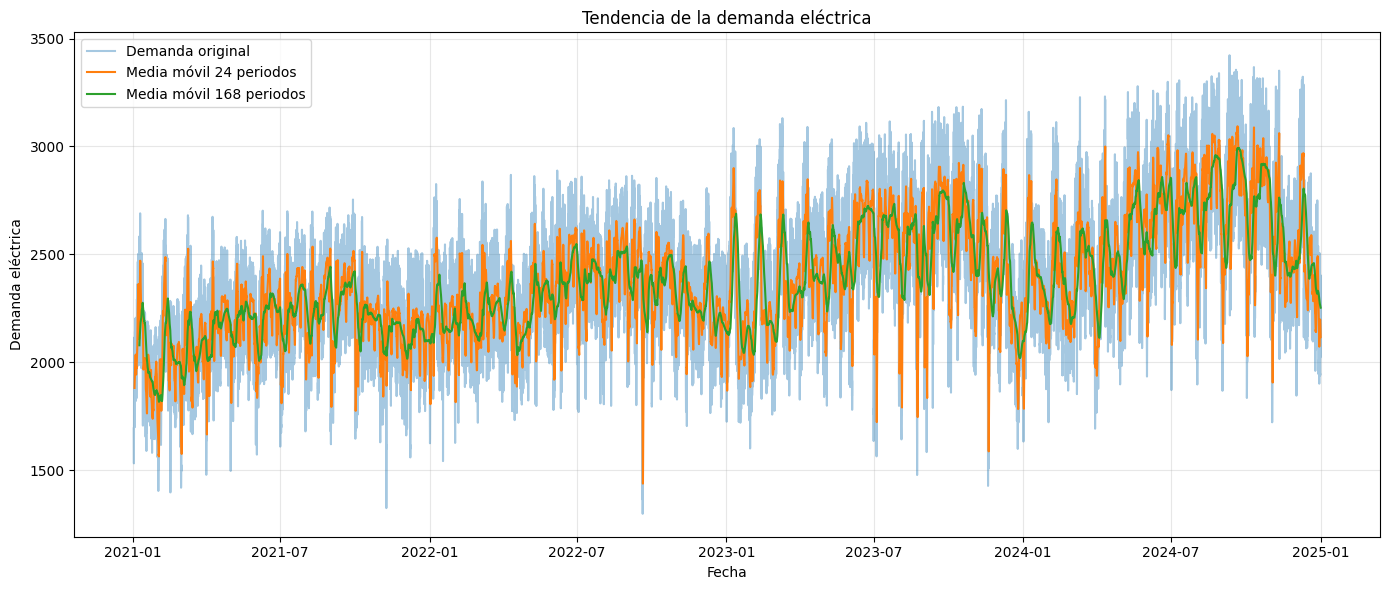

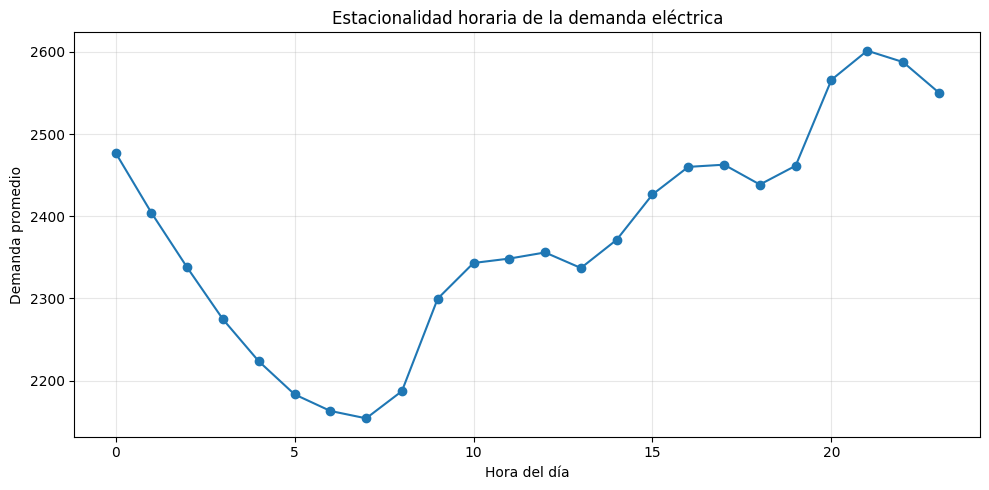

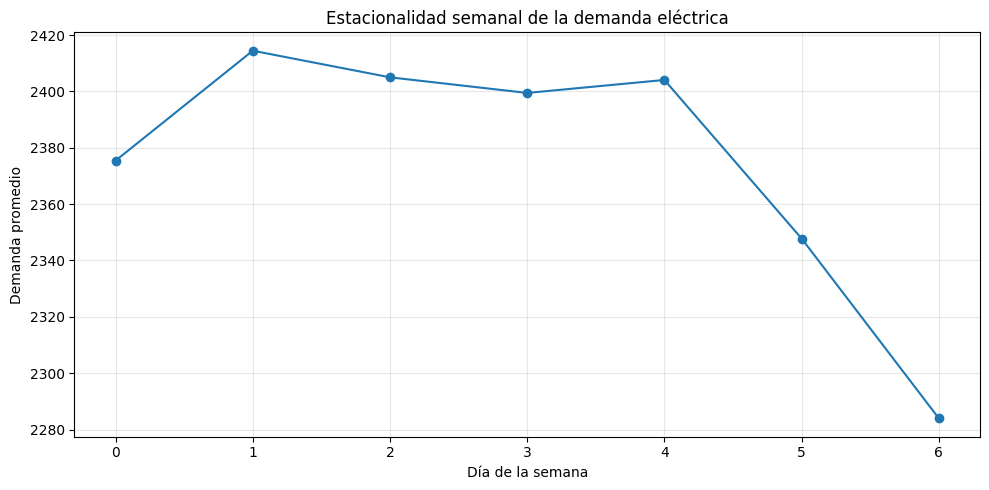

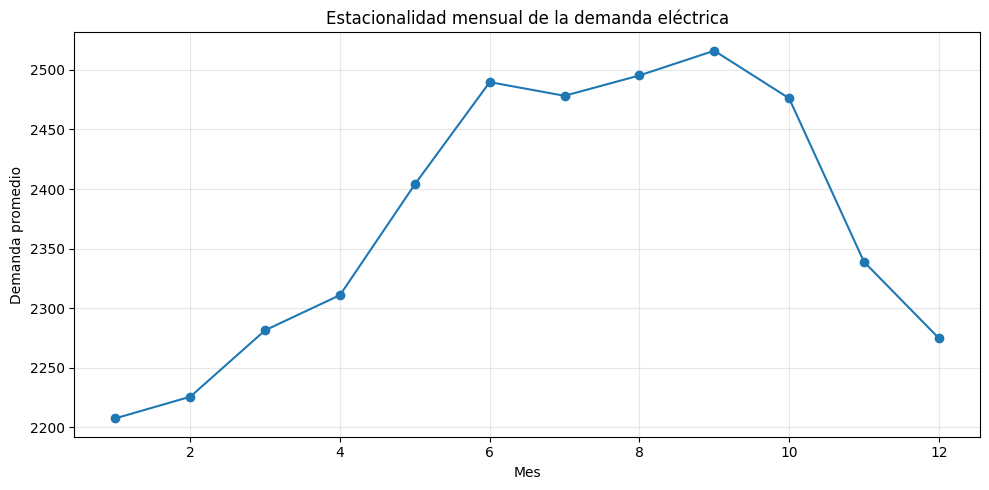

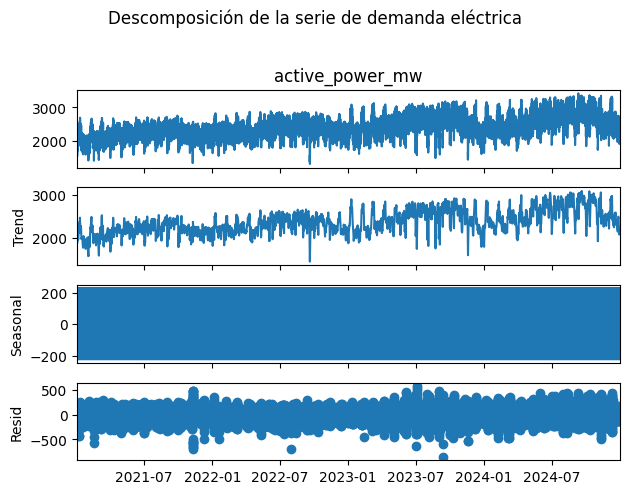

=== AUTOCORRELACIÓN EN REZAGOS CLAVE ===
ACF lag 24 horas: 0.7647919341961692
ACF lag 168 horas: 0.5227933361303173
Se observa posible estacionalidad diaria de 24 horas.
Se observa posible estacionalidad semanal de 168 horas.


<Figure size 1400x500 with 0 Axes>

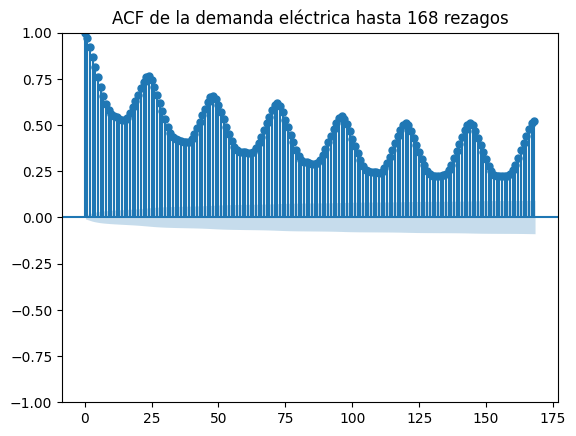

<Figure size 1400x500 with 0 Axes>

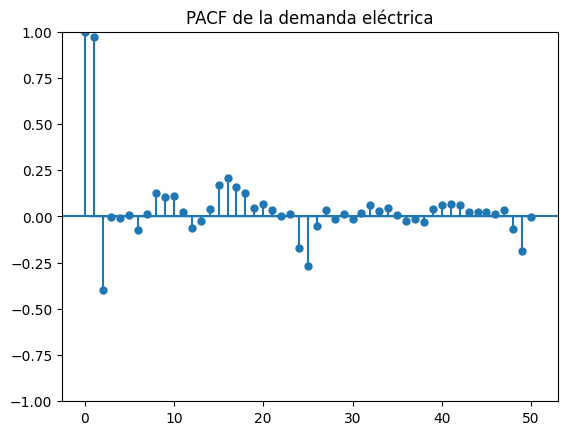

------------------------------------
Pruebas de estacionariedad para la serie original
===> Test: ADF
H0: La serie NO es estacionaria
H1: La serie es estacionaria
p-value: 0.000000
Se RECHAZA H0
Evidencia a favor de: La serie es estacionaria

===> Test: KPSS
H0: La serie es estacionaria
H1: La serie NO es estacionaria
p-value: 0.010000
Se RECHAZA H0
Evidencia a favor de: La serie NO es estacionaria

------------------------------------
Serie diferenciada de primer orden


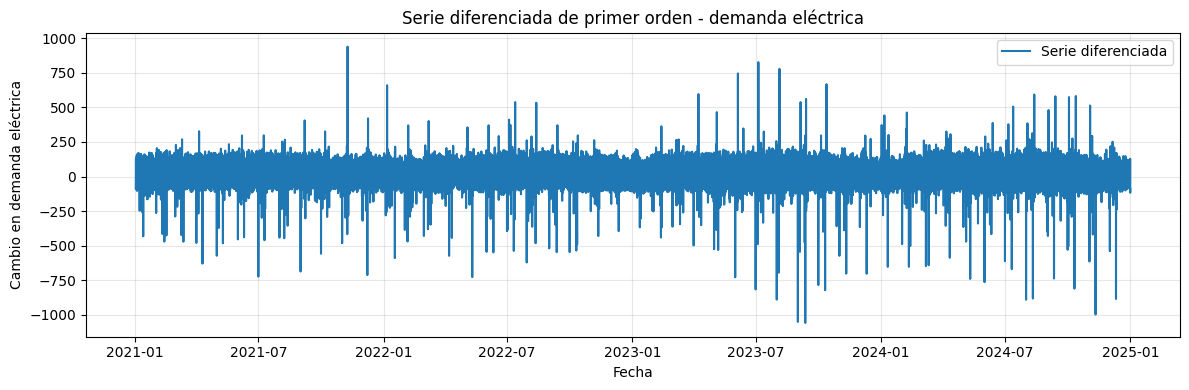

Pruebas de estacionariedad para la serie diferenciada
===> Test: ADF
H0: La serie NO es estacionaria
H1: La serie es estacionaria
p-value: 0.000000
Se RECHAZA H0
Evidencia a favor de: La serie es estacionaria

===> Test: KPSS
H0: La serie es estacionaria
H1: La serie NO es estacionaria
p-value: 0.100000
NO se rechaza H0
No hay evidencia suficiente contra: La serie es estacionaria

------------------------------------
=== RESPUESTAS PRELIMINARES DEL EDA ===

1. ¿Hay valores faltantes?
No hay valores faltantes.

2. ¿Hay valores atípicos?
Sí, hay 181, valores atípicos.
Representan aproximadamente el 0.52del dataset.
No se eliminaron porque pueden representar comportamientos reales de la demanda eléctrica.

3. ¿Hay estacionalidad?
Sí, se observa estacionalidad diaria, semanal y mensual en la demanda eléctrica.
La ACF mostró autocorrelaciones altas en los rezagos 24 y 168,
lo que indica patrones repetitivos diarios y semanales.
Además, las gráficas por mes muestran variaciones mensuales en 

In [5]:
# =========================================================
# 1.4 VISUALIZACIÓN DE LA SERIE TEMPORAL
# =========================================================

plt.figure(figsize=(14, 5))
plt.plot(df[fecha_col], df[target_col])
plt.title("Serie temporal de demanda eléctrica")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.5 DISTRIBUCIÓN DE LA DEMANDA ELÉCTRICA
# Histograma + KDE
# =========================================================

data_demanda = df[target_col].dropna()

x = np.linspace(data_demanda.min(), data_demanda.max(), 1000)
kde = gaussian_kde(data_demanda)

plt.figure(figsize=(10, 5))
plt.hist(data_demanda, bins=30, density=True, alpha=0.6, label="Histograma")
plt.plot(x, kde(x), linewidth=2, label="KDE")
plt.title("Distribución de la demanda eléctrica")
plt.xlabel("Demanda eléctrica")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.6 DETECCIÓN DE VALORES ATÍPICOS
# Método IQR
# =========================================================

Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df[target_col] < limite_inferior) |
    (df[target_col] > limite_superior)
]

print("=== DETECCIÓN DE VALORES ATÍPICOS ===")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
atipicos = len(outliers)
print("Cantidad de valores atípicos:", atipicos)
prcnt_atipico = round((atipicos / len(df)) * 100, 2)
print("Porcentaje de valores atípicos:", prcnt_atipico, "%")

plt.figure(figsize=(10, 4))
plt.boxplot(df[target_col].dropna(), vert=False)
plt.title("Boxplot de demanda eléctrica")
plt.xlabel("Demanda eléctrica")
plt.tight_layout()
plt.show()

display(outliers.head())

# =========================================================
# 1.7 ANÁLISIS DE TENDENCIA
# Media móvil
# =========================================================

df["media_movil_24"] = df[target_col].rolling(window=24).mean()
df["media_movil_168"] = df[target_col].rolling(window=168).mean()

plt.figure(figsize=(14, 6))
plt.plot(df[fecha_col], df[target_col], alpha=0.4, label="Demanda original")
plt.plot(df[fecha_col], df["media_movil_24"], label="Media móvil 24 periodos")
plt.plot(df[fecha_col], df["media_movil_168"], label="Media móvil 168 periodos")
plt.title("Tendencia de la demanda eléctrica")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.8 ESTACIONALIDAD HORARIA
# Si el dataset tiene datos horarios
# =========================================================

df["hora"] = df[fecha_col].dt.hour

promedio_hora = df.groupby("hora")[target_col].mean()

plt.figure(figsize=(10, 5))
plt.plot(promedio_hora.index, promedio_hora.values, marker="o")
plt.title("Estacionalidad horaria de la demanda eléctrica")
plt.xlabel("Hora del día")
plt.ylabel("Demanda promedio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.9 ESTACIONALIDAD SEMANAL
# =========================================================

df["dia_semana"] = df[fecha_col].dt.dayofweek

promedio_dia = df.groupby("dia_semana")[target_col].mean()

plt.figure(figsize=(10, 5))
plt.plot(promedio_dia.index, promedio_dia.values, marker="o")
plt.title("Estacionalidad semanal de la demanda eléctrica")
plt.xlabel("Día de la semana")
plt.ylabel("Demanda promedio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.10 ESTACIONALIDAD MENSUAL
# =========================================================

df["mes"] = df[fecha_col].dt.month

promedio_mes = df.groupby("mes")[target_col].mean()

plt.figure(figsize=(10, 5))
plt.plot(promedio_mes.index, promedio_mes.values, marker="o")
plt.title("Estacionalidad mensual de la demanda eléctrica")
plt.xlabel("Mes")
plt.ylabel("Demanda promedio")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 1.11 DESCOMPOSICIÓN DE LA SERIE TEMPORAL
# Ajustamos periodo según la frecuencia:
# Datos horarios: period=24
# Datos diarios: period=7
# Datos mensuales: period=12
# =========================================================

serie = df.set_index(fecha_col)[target_col].dropna()

# Cambia el periodo si el dataset no es horario
periodo_estacional = 24

descomposicion = seasonal_decompose(
    serie,
    model="additive",
    period=periodo_estacional
)

descomposicion.plot()
plt.suptitle("Descomposición de la serie de demanda eléctrica", y=1.02)
plt.tight_layout()
plt.show()

# =========================================================
# 1.12 ACF Y PACF PARA ESTACIONALIDAD Y MODELOS ARIMA/SARIMA
# =========================================================

serie = df.set_index(fecha_col)[target_col].dropna()

# ACF hasta 168 rezagos porque el dataset es horario:
# 24 rezagos = 24 horas = patrón diario
# 168 rezagos = 24 * 7 = patrón semanal
acf_vals = acf(serie, nlags=168)

print("=== AUTOCORRELACIÓN EN REZAGOS CLAVE ===")
print("ACF lag 24 horas:", acf_vals[24])
print("ACF lag 168 horas:", acf_vals[168])

if abs(acf_vals[24]) > 0.3:
    print("Se observa posible estacionalidad diaria de 24 horas.")

if abs(acf_vals[168]) > 0.3:
    print("Se observa posible estacionalidad semanal de 168 horas.")

plt.figure(figsize=(14, 5))
plot_acf(serie, lags=168)
plt.title("ACF de la demanda eléctrica hasta 168 rezagos")
plt.show()

plt.figure(figsize=(14, 5))
plot_pacf(serie, lags=50, method="ywm")
plt.title("PACF de la demanda eléctrica")
plt.show()

# =========================================================
# 1.13 PRUEBAS DE ESTACIONARIEDAD ADF Y KPSS
# =========================================================

from statsmodels.tsa.stattools import adfuller, kpss

def interpretar_test(nombre, pvalue, alpha, H0, H1):
    print(f"===> Test: {nombre}")
    print(f"H0: {H0}")
    print(f"H1: {H1}")
    print(f"p-value: {pvalue:.6f}")

    if pvalue < alpha:
        print("Se RECHAZA H0")
        print(f"Evidencia a favor de: {H1}")
    else:
        print("NO se rechaza H0")
        print(f"No hay evidencia suficiente contra: {H0}")
    print("")


def adf_test(series):
    result = adfuller(series.dropna())

    interpretar_test(
        "ADF",
        result[1],
        0.05,
        "La serie NO es estacionaria",
        "La serie es estacionaria"
    )


def kpss_test(series):
    result = kpss(series.dropna(), regression="c", nlags="auto")

    interpretar_test(
        "KPSS",
        result[1],
        0.05,
        "La serie es estacionaria",
        "La serie NO es estacionaria"
    )


# Serie original
ts = df.set_index(fecha_col)[target_col].dropna()

print("------------------------------------")
print("Pruebas de estacionariedad para la serie original")
adf_test(ts)
kpss_test(ts)


# Serie diferenciada de primer orden
print("------------------------------------")
print("Serie diferenciada de primer orden")

ts_diff = ts.diff().dropna()

plt.figure(figsize=(12, 4))
plt.plot(ts_diff, label="Serie diferenciada")
plt.title("Serie diferenciada de primer orden - demanda eléctrica")
plt.xlabel("Fecha")
plt.ylabel("Cambio en demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("Pruebas de estacionariedad para la serie diferenciada")
adf_test(ts_diff)
kpss_test(ts_diff)

print("------------------------------------")

# =========================================================
# 1.14 RESPUESTAS PRELIMINARES DEL EDA
# =========================================================

print("=== RESPUESTAS PRELIMINARES DEL EDA ===")

print("\n1. ¿Hay valores faltantes?")
if total_faltantes == 0:
    print("No hay valores faltantes.")
else:
  print("Sí, el total de valores faltantes es:", total_faltantes)

print("\n2. ¿Hay valores atípicos?")
if atipicos == 0:
    print("No hay valores atípicos.")
else:
    print(f"Sí, hay {atipicos}, valores atípicos.")
    print(f"Representan aproximadamente el {prcnt_atipico}del dataset.")
    print("No se eliminaron porque pueden representar comportamientos reales de la demanda eléctrica.")

print("\n3. ¿Hay estacionalidad?")
print("Sí, se observa estacionalidad diaria, semanal y mensual en la demanda eléctrica.")
print("La ACF mostró autocorrelaciones altas en los rezagos 24 y 168,")
print("lo que indica patrones repetitivos diarios y semanales.")
print("Además, las gráficas por mes muestran variaciones mensuales en la demanda.")

print("\n4. ¿La serie es estacionaria?")
print("La estacionariedad se evaluó mediante las pruebas ADF y KPSS sobre la serie original y diferenciada.")

print("\n5. ¿Hay tendencia?")
print("Sí, se observa una tendencia creciente y cambiante en la demanda eléctrica.")
print("La serie temporal y las medias móviles muestran incrementos graduales\a lo largo del periodo analizado.")

# =========================================================
# 1.15 PREPARACIÓN DE DATASET PARA MODELADO
# =========================================================

# Dataset base para modelado
df_modelo = df.copy()

# Crear lag semanal porque la ACF mostró estacionalidad semanal
df_modelo["active_power_lag_168h"] = df_modelo[target_col].shift(168)

# Medias móviles usando solo datos pasados para evitar data leakage
df_modelo["media_movil_24"] = df_modelo[target_col].shift(1).rolling(window=24).mean()
df_modelo["media_movil_168"] = df_modelo[target_col].shift(1).rolling(window=168).mean()

# Variables de calendario si quieres mantener nombres consistentes
df_modelo["dia_semana"] = df_modelo[fecha_col].dt.dayofweek

# Variables de calendario adicionales
df_modelo["dia_mes"] = df_modelo[fecha_col].dt.day
df_modelo["dia_anio"] = df_modelo[fecha_col].dt.dayofyear
df_modelo["semana_anio"] = df_modelo[fecha_col].dt.isocalendar().week.astype(int)
df_modelo["trimestre"] = df_modelo[fecha_col].dt.quarter
df_modelo["anio"] = df_modelo[fecha_col].dt.year

# Codificación cíclica para variables temporales
df_modelo["hour_sin"] = np.sin(2 * np.pi * df_modelo["hour"] / 24)
df_modelo["hour_cos"] = np.cos(2 * np.pi * df_modelo["hour"] / 24)

df_modelo["month_sin"] = np.sin(2 * np.pi * df_modelo["month"] / 12)
df_modelo["month_cos"] = np.cos(2 * np.pi * df_modelo["month"] / 12)

df_modelo["dia_semana_sin"] = np.sin(2 * np.pi * df_modelo["dia_semana"] / 7)
df_modelo["dia_semana_cos"] = np.cos(2 * np.pi * df_modelo["dia_semana"] / 7)

# Eliminar NaN generados por lags/medias móviles
df_modelo = df_modelo.dropna().reset_index(drop=True)

print(f"\nDataset para modelado: {df_modelo.shape}")

## 2. Modelado

In [6]:
# =========================================================
# 2. PREPARACIÓN GENERAL PARA MODELADO
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Serie temporal principal para modelos estadísticos y SARIMA
ts = df_modelo.set_index(fecha_col)[target_col]

# División 80/20 respetando el orden temporal
train_size = int(len(df_modelo) * 0.8)

df_train = df_modelo.iloc[:train_size].copy()
df_test = df_modelo.iloc[train_size:].copy()

ts_train = df_train.set_index(fecha_col)[target_col]
ts_test = df_test.set_index(fecha_col)[target_col]

print("Tamaño df_modelo:", df_modelo.shape)
print("Tamaño entrenamiento:", df_train.shape)
print("Tamaño prueba:", df_test.shape)
print("Inicio train:", df_train[fecha_col].min())
print("Fin train:", df_train[fecha_col].max())
print("Inicio test:", df_test[fecha_col].min())
print("Fin test:", df_test[fecha_col].max())

# =========================================================
# 2.1 FUNCIÓN DE MÉTRICAS
# =========================================================

def calcular_metricas_modelo(y_real, y_pred, nombre_modelo):
    y_real = np.array(y_real)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)

    y_safe = np.where(y_real == 0, np.nan, y_real)
    mape = np.nanmean(np.abs((y_real - y_pred) / y_safe)) * 100

    denominador = (np.abs(y_real) + np.abs(y_pred)) / 2
    denominador = np.where(denominador == 0, np.nan, denominador)
    smape = np.nanmean(np.abs(y_real - y_pred) / denominador) * 100

    return {
        "Modelo": nombre_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape
    }

# =========================================================
# 2.2 CONTENEDORES DE RESULTADOS
# =========================================================

resultados_modelos = []
predicciones_modelos = {}

Tamaño df_modelo: (34871, 50)
Tamaño entrenamiento: (27896, 50)
Tamaño prueba: (6975, 50)
Inicio train: 2021-01-09 00:00:00
Fin train: 2024-03-16 08:00:00
Inicio test: 2024-03-16 09:00:00
Fin test: 2024-12-31 23:00:00


## 3. TES / HOLT-WINTERS

Entrenando modelo TES / Holt-Winters...
Métricas TES / Holt-Winters:
{'Modelo': 'TES_Holt_Winters', 'MAE': 259.2542499736014, 'MSE': 100603.16010911313, 'RMSE': np.float64(317.1800121525837), 'MAPE': np.float64(9.64351748791778), 'sMAPE': np.float64(10.004195748352693)}


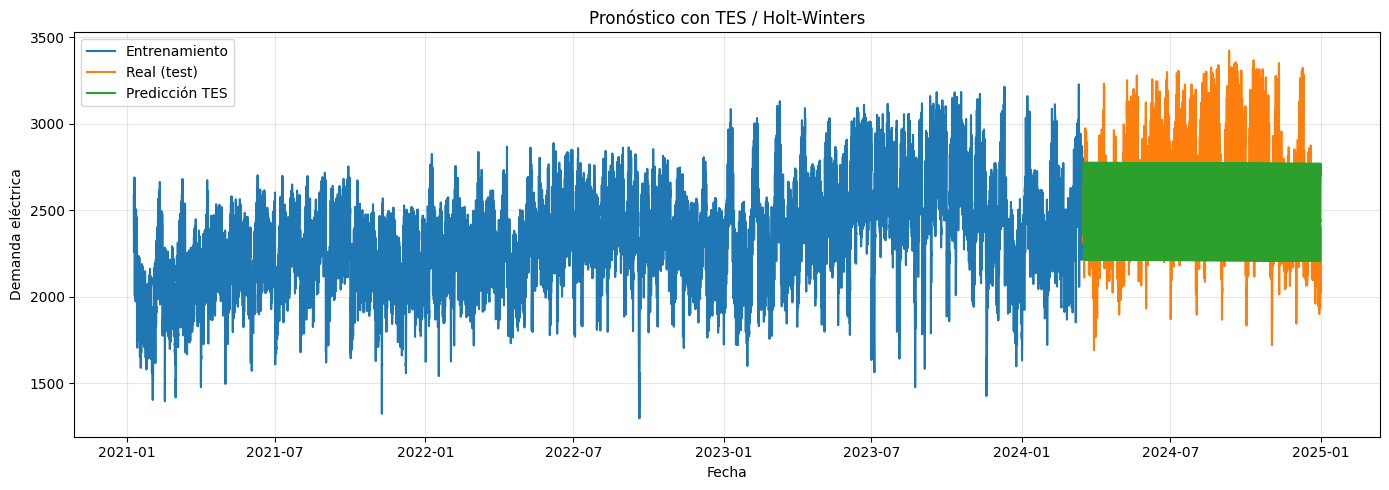


El modelo TES captura el patrón estacional general, pero suaviza demasiado los picos de demanda.


In [7]:
# =========================================================
# 3. MODELO ESTADÍSTICO: TES / HOLT-WINTERS
# =========================================================

from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Entrenando modelo TES / Holt-Winters...")

# Para datos horarios:
# seasonal_periods=24 representa estacionalidad diaria
# También podrías probar 168 para semanal, pero 24 es más ligero para iniciar

modelo_tes = ExponentialSmoothing(
    ts_train,
    trend="add",
    seasonal="add",
    seasonal_periods=24
).fit(optimized=True)

pred_tes = modelo_tes.forecast(steps=len(ts_test))

# Forzar que las predicciones usen las mismas fechas del conjunto de prueba
pred_tes = pd.Series(
    pred_tes.values,
    index=ts_test.index,
    name="Predicción TES"
)

# Guardar predicciones
predicciones_modelos["TES_Holt_Winters"] = pred_tes

# Calcular métricas
metricas_tes = calcular_metricas_modelo(
    ts_test.values,
    pred_tes.values,
    "TES_Holt_Winters"
)

resultados_modelos.append(metricas_tes)

print("Métricas TES / Holt-Winters:")
print(metricas_tes)

# =========================================================
# 3.1 GRÁFICA TES / HOLT-WINTERS
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(ts_train.index, ts_train.values, label="Entrenamiento")
plt.plot(ts_test.index, ts_test.values, label="Real (test)")
plt.plot(pred_tes.index, pred_tes.values, label="Predicción TES")

plt.title("Pronóstico con TES / Holt-Winters")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\nEl modelo TES captura el patrón estacional general, pero suaviza demasiado los picos de demanda.")

## 4. MODELO SARIMA

Entrenando modelo SARIMA...
Métricas SARIMA:
{'Modelo': 'SARIMA', 'MAE': 244.9965359934115, 'MSE': 83965.3076638354, 'RMSE': np.float64(289.7676787770427), 'MAPE': np.float64(9.56349007892341), 'sMAPE': np.float64(9.391212103513457)}


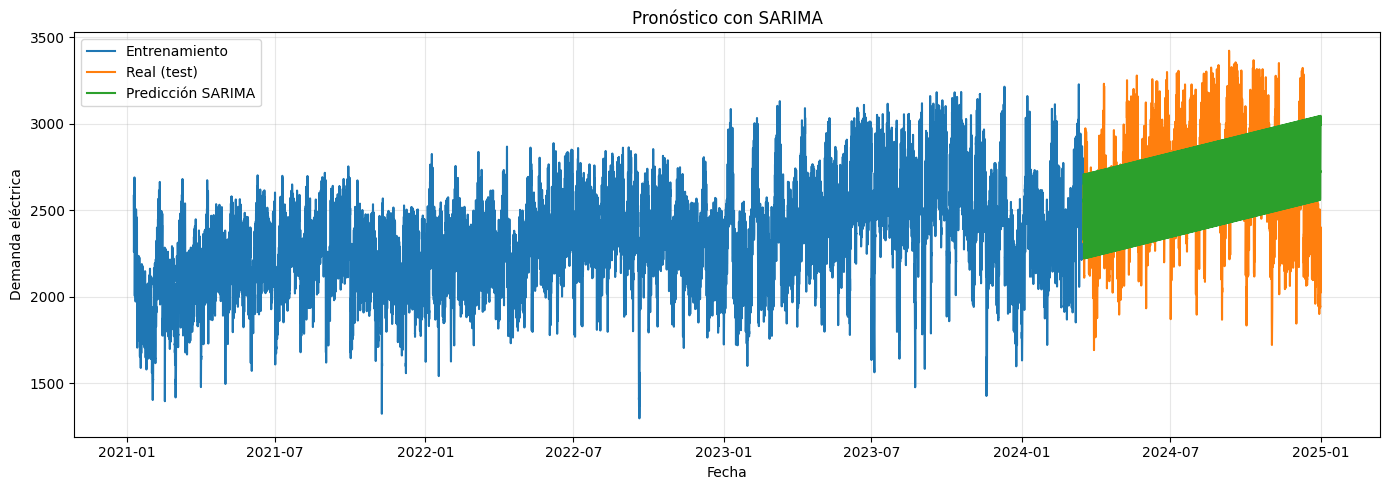

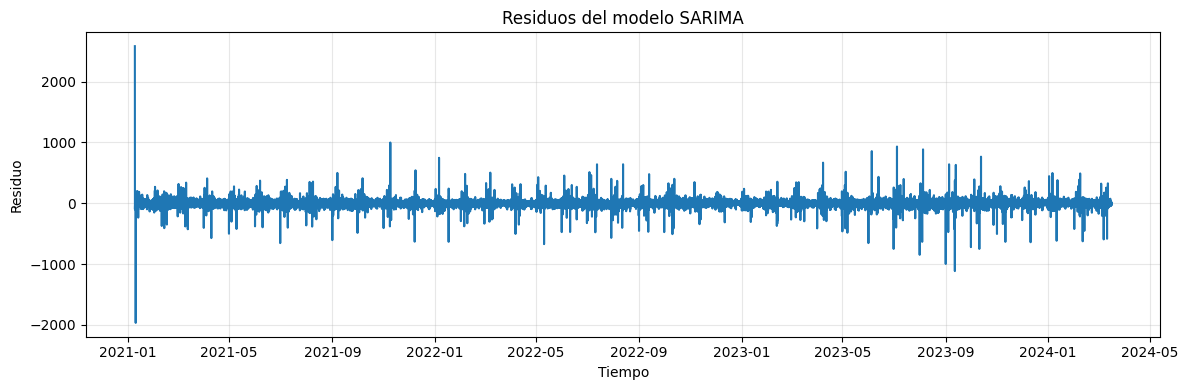

Media de residuos: 0.08792187621598448
Desviación estándar: 56.40316757061101


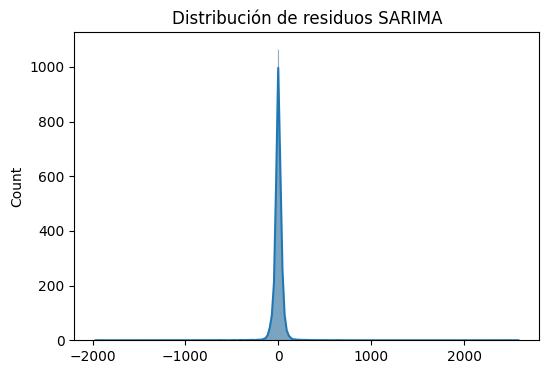

In [8]:
# =========================================================
# 4. MODELO SARIMA
# =========================================================

from statsmodels.tsa.statespace.sarimax import SARIMAX

print("Entrenando modelo SARIMA...")

# SARIMA con estacionalidad diaria:
# order=(p,d,q)
# seasonal_order=(P,D,Q,s)
# s=24 porque los datos son horarios y se observó estacionalidad diaria

modelo_sarima = SARIMAX(
    ts_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

pred_sarima = modelo_sarima.forecast(steps=len(ts_test))

# Forzar índice correcto del conjunto test
pred_sarima = pd.Series(
    pred_sarima.values,
    index=ts_test.index,
    name="Predicción SARIMA"
)

# Guardar predicciones
predicciones_modelos["SARIMA"] = pred_sarima

# Calcular métricas
metricas_sarima = calcular_metricas_modelo(
    ts_test.values,
    pred_sarima.values,
    "SARIMA"
)

resultados_modelos.append(metricas_sarima)

print("Métricas SARIMA:")
print(metricas_sarima)

# =========================================================
# 4.1 GRÁFICA SARIMA
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(ts_train.index, ts_train.values, label="Entrenamiento")
plt.plot(ts_test.index, ts_test.values, label="Real (test)")
plt.plot(pred_sarima.index, pred_sarima.values, label="Predicción SARIMA")

plt.title("Pronóstico con SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 4.2 ANÁLISIS DE RESIDUOS SARIMA
# =========================================================

residuos_sarima = modelo_sarima.resid

plt.figure(figsize=(12,4))
plt.plot(residuos_sarima)
plt.title("Residuos del modelo SARIMA")
plt.xlabel("Tiempo")
plt.ylabel("Residuo")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Media de residuos:", residuos_sarima.mean())
print("Desviación estándar:", residuos_sarima.std())

plt.figure(figsize=(6,4))
sns.histplot(residuos_sarima, kde=True)
plt.title("Distribución de residuos SARIMA")
plt.show()

## 5. MODELO ML: XGBOOST

Entrenando modelo XGBoost...
Cantidad de features usadas: 46
['apparent_temperature_c', 'cloud_cover_percent', 'month', 'hour', 'is_holiday', 'is_weekend', 'is_school_vacation', 'dia_semana', 'media_movil_24', 'media_movil_168', 'active_power_lag_168h', 'dia_mes', 'dia_anio', 'semana_anio', 'trimestre', 'anio', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'dia_semana_sin', 'dia_semana_cos', 'active_power_lag_1h', 'active_power_lag_2h', 'active_power_lag_3h', 'active_power_lag_4h', 'active_power_lag_5h', 'active_power_lag_6h', 'active_power_lag_7h', 'active_power_lag_8h', 'active_power_lag_9h', 'active_power_lag_10h', 'active_power_lag_11h', 'active_power_lag_12h', 'active_power_lag_13h', 'active_power_lag_14h', 'active_power_lag_15h', 'active_power_lag_16h', 'active_power_lag_17h', 'active_power_lag_18h', 'active_power_lag_19h', 'active_power_lag_20h', 'active_power_lag_21h', 'active_power_lag_22h', 'active_power_lag_23h', 'active_power_lag_24h']
Realizando búsqueda de parámetros 

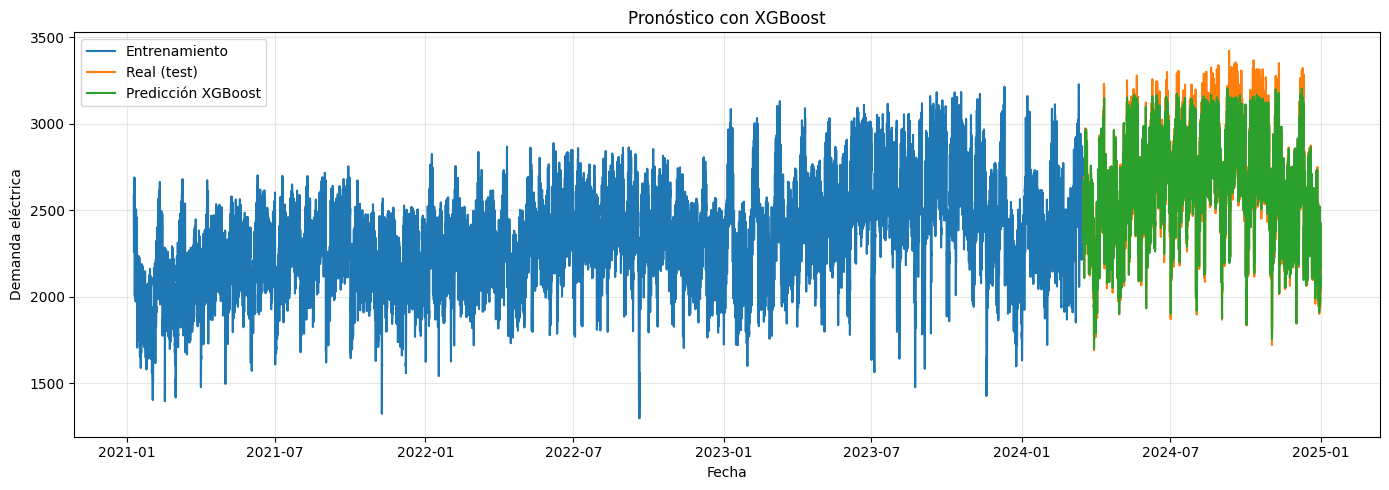

,feature,importance
22,active_power_lag_1h,0.879855
44,active_power_lag_23h,0.029198
3,hour,0.016734
17,hour_cos,0.009859
16,hour_sin,0.005736
26,active_power_lag_5h,0.005236
5,is_weekend,0.004726
23,active_power_lag_2h,0.004631
19,month_cos,0.003387
2,month,0.002311


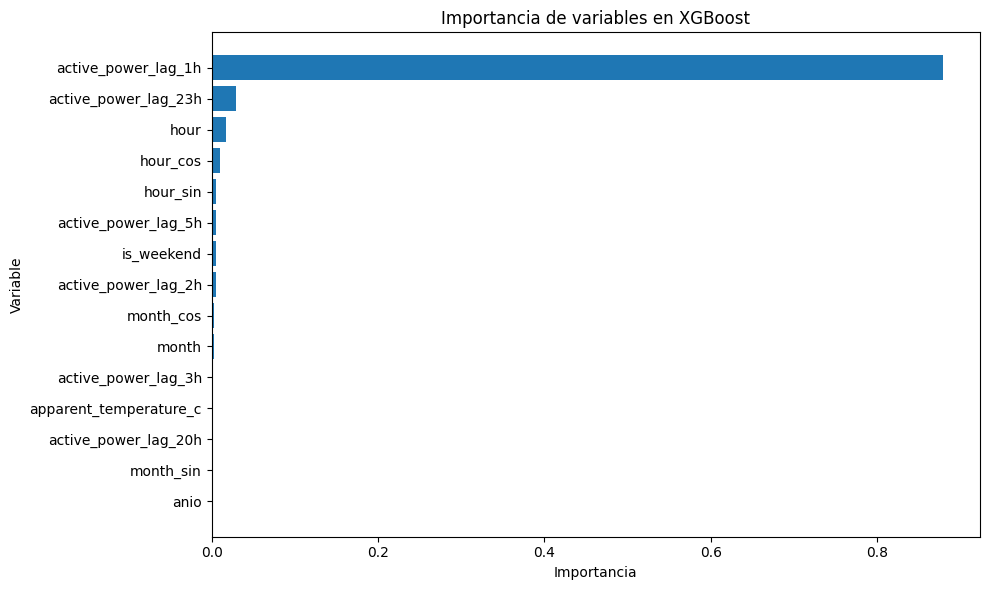

In [9]:
# =========================================================
# 5. MODELO MACHINE LEARNING: XGBOOST
# =========================================================

from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

print("Entrenando modelo XGBoost...")

# =========================================================
# FEATURES DINÁMICAS PARA MACHINE LEARNING
# =========================================================

features_base = [
    "apparent_temperature_c",
    "cloud_cover_percent",
    "month",
    "hour",
    "is_holiday",
    "is_weekend",
    "is_school_vacation",
    "dia_semana",
    "media_movil_24",
    "media_movil_168",
    "active_power_lag_168h",
    "dia_mes",
    "dia_anio",
    "semana_anio",
    "trimestre",
    "anio",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
    "dia_semana_sin",
    "dia_semana_cos",
]

features_lags = [
    col for col in df_modelo.columns
    if col.startswith("active_power_lag_")
]

features_ml = features_base + features_lags
features_ml = list(dict.fromkeys(features_ml))

features_ml = [
    col for col in features_ml
    if col in df_modelo.columns
]

print("Cantidad de features usadas:", len(features_ml))
print(features_ml)

# =========================================================
# SEPARAR X / y
# =========================================================

X_train = df_train[features_ml]
y_train = df_train[target_col]

X_test = df_test[features_ml]
y_test = df_test[target_col]

# =========================================================
# AJUSTE DE HIPERPARÁMETROS CON TIMESERIESSPLIT
# =========================================================

print("Realizando búsqueda de parámetros para XGBoost...")

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

param_grid_xgb = {
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros XGBoost:")
print(grid_xgb.best_params_)

print("Mejor RMSE en validación:")
print(-grid_xgb.best_score_)

# =========================================================
# ENTRENAR MODELO FINAL CON LOS MEJORES PARÁMETROS
# =========================================================

modelo_xgb = XGBRegressor(
    **grid_xgb.best_params_,
    objective="reg:squarederror",
    random_state=42
)

modelo_xgb.fit(X_train, y_train)

pred_xgb = modelo_xgb.predict(X_test)

pred_xgb = pd.Series(
    pred_xgb,
    index=df_test[fecha_col],
    name="Predicción XGBoost"
)

predicciones_modelos["XGBoost"] = pred_xgb

metricas_xgb = calcular_metricas_modelo(
    y_test.values,
    pred_xgb.values,
    "XGBoost"
)

resultados_modelos.append(metricas_xgb)

print("Métricas XGBoost:")
print(metricas_xgb)

# =========================================================
# 5.1 GRÁFICA XGBOOST
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(df_train[fecha_col], y_train, label="Entrenamiento")
plt.plot(df_test[fecha_col], y_test, label="Real (test)")
plt.plot(pred_xgb.index, pred_xgb.values, label="Predicción XGBoost")

plt.title("Pronóstico con XGBoost")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =========================================================
# 5.2 IMPORTANCIA DE VARIABLES XGBOOST
# =========================================================

importancias_xgb = pd.DataFrame({
    "feature": features_ml,
    "importance": modelo_xgb.feature_importances_
}).sort_values("importance", ascending=False)

display(importancias_xgb)

plt.figure(figsize=(10, 6))
plt.barh(
    importancias_xgb["feature"].head(15)[::-1],
    importancias_xgb["importance"].head(15)[::-1]
)
plt.title("Importancia de variables en XGBoost")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

## 6. MODELO DEEP LEARNING: LSTM

Entrenando modelo LSTM...
Shape X_seq: (34847, 24, 46)
Shape y_seq: (34847, 1)
Tamaño X_train_lstm: (27877, 24, 46)
Tamaño X_test_lstm: (6970, 24, 46)
Epoch 1/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.0057 - val_loss: 0.0072
Epoch 2/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0029 - val_loss: 0.0039
Epoch 3/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - val_loss: 0.0031
Epoch 4/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0019 - val_loss: 0.0031
Epoch 5/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0016 - val_loss: 0.0033
Epoch 6/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0014 - val_loss: 0.0034
Epoch 7/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0013 - val_loss: 0.0034
Epoch 8/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0012 - val_loss: 0.0020
Epoch 9/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 10/30
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0011 - val

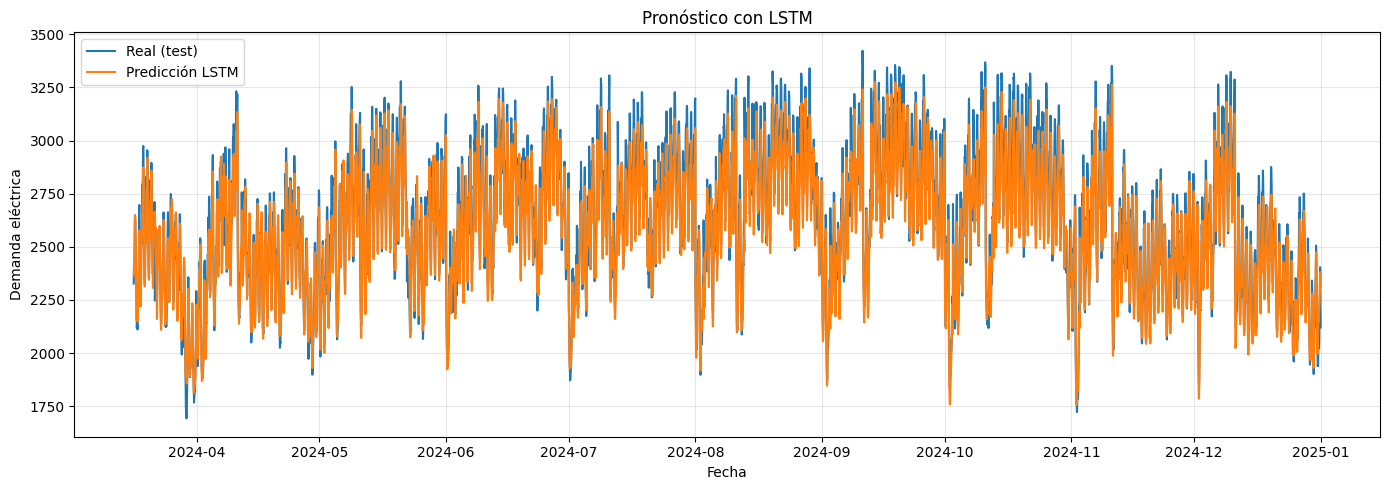

In [10]:
# =========================================================
# 6. MODELO DEEP LEARNING: LSTM
# =========================================================

from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("Entrenando modelo LSTM...")

# Features para LSTM
features_lstm = features_ml.copy()

# Escalado de X
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_lstm = df_modelo[features_lstm].values
y_lstm = df_modelo[[target_col]].values

X_lstm_scaled = scaler_X.fit_transform(X_lstm)
y_lstm_scaled = scaler_y.fit_transform(y_lstm)

# Crear secuencias
def crear_secuencias(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y[i])

    return np.array(X_seq), np.array(y_seq)

window_size = 24

X_seq, y_seq = crear_secuencias(
    X_lstm_scaled,
    y_lstm_scaled,
    window_size
)

print("Shape X_seq:", X_seq.shape)
print("Shape y_seq:", y_seq.shape)

# =========================================================
# 6.1 TRAIN/TEST PARA LSTM
# =========================================================

train_size_lstm = int(len(X_seq) * 0.8)

X_train_lstm = X_seq[:train_size_lstm]
X_test_lstm = X_seq[train_size_lstm:]

y_train_lstm = y_seq[:train_size_lstm]
y_test_lstm = y_seq[train_size_lstm:]

# Fechas correspondientes al test
fechas_lstm = df_modelo[fecha_col].iloc[window_size:].reset_index(drop=True)
fechas_test_lstm = fechas_lstm.iloc[train_size_lstm:]

print("Tamaño X_train_lstm:", X_train_lstm.shape)
print("Tamaño X_test_lstm:", X_test_lstm.shape)

# =========================================================
# 6.2 ENTRENAMIENTO LSTM
# =========================================================

modelo_lstm = Sequential([
    LSTM(64, activation="tanh", return_sequences=False, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

modelo_lstm.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

historial_lstm = modelo_lstm.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# 6.3 PREDICCIÓN Y MÉTRICAS LSTM
# =========================================================

pred_lstm_scaled = modelo_lstm.predict(X_test_lstm)

pred_lstm = scaler_y.inverse_transform(pred_lstm_scaled).flatten()
y_test_lstm_real = scaler_y.inverse_transform(y_test_lstm).flatten()

pred_lstm = pd.Series(
    pred_lstm,
    index=fechas_test_lstm.values,
    name="Predicción LSTM"
)

predicciones_modelos["LSTM"] = pred_lstm

metricas_lstm = calcular_metricas_modelo(
    y_test_lstm_real,
    pred_lstm.values,
    "LSTM"
)

resultados_modelos.append(metricas_lstm)

print("Métricas LSTM:")
print(metricas_lstm)

# =========================================================
# 6.4 GRÁFICA LSTM
# =========================================================

plt.figure(figsize=(14, 5))

plt.plot(fechas_test_lstm.values, y_test_lstm_real, label="Real (test)")
plt.plot(pred_lstm.index, pred_lstm.values, label="Predicción LSTM")

plt.title("Pronóstico con LSTM")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. COMPARACIÓN FINAL DE MÉTRICAS

=== COMPARACIÓN FINAL DE MÉTRICAS ===


,Modelo,MAE,MSE,RMSE,MAPE,sMAPE
0,XGBoost,31.2500,2152.8337,46.3986,1.1430,1.1487
1,LSTM,69.7304,8524.4195,92.3278,2.5989,2.6291
2,SARIMA,244.9965,83965.3077,289.7677,9.5635,9.3912
3,TES_Holt_Winters,259.2542,100603.1601,317.1800,9.6435,10.0042



=== MEJOR MODELO ===
Modelo: XGBoost
MAE: 31.25
RMSE: 46.3986
MAPE: 1.143
sMAPE: 1.1487


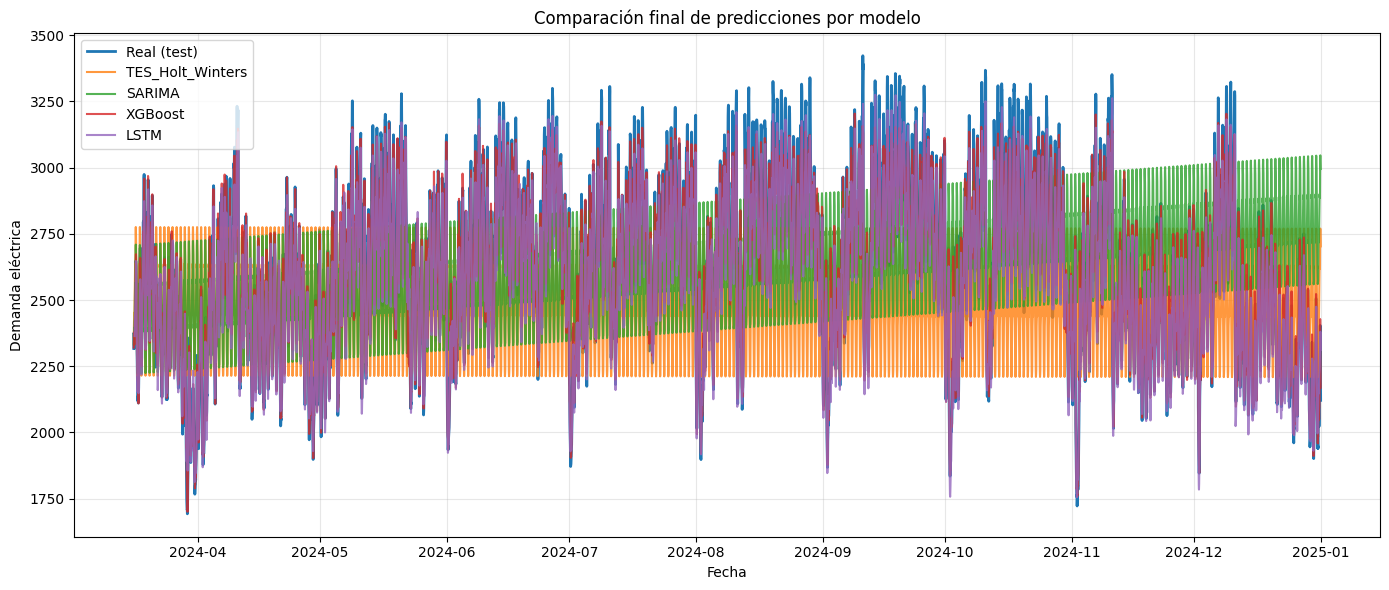

In [11]:
# =========================================================
# 7. COMPARACIÓN FINAL DE MÉTRICAS
# =========================================================

df_comparacion_metricas = pd.DataFrame(resultados_modelos)

df_comparacion_metricas = df_comparacion_metricas[
    ["Modelo", "MAE", "MSE", "RMSE", "MAPE", "sMAPE"]
].round(4)

df_comparacion_metricas = df_comparacion_metricas.sort_values(
    by=["RMSE", "MAE"]
).reset_index(drop=True)

print("=== COMPARACIÓN FINAL DE MÉTRICAS ===")
display(df_comparacion_metricas)

mejor_modelo = df_comparacion_metricas.iloc[0]

print("\n=== MEJOR MODELO ===")
print("Modelo:", mejor_modelo["Modelo"])
print("MAE:", mejor_modelo["MAE"])
print("RMSE:", mejor_modelo["RMSE"])
print("MAPE:", mejor_modelo["MAPE"])
print("sMAPE:", mejor_modelo["sMAPE"])

# =========================================================
# 7.1 GRÁFICA COMPARATIVA FINAL
# =========================================================

plt.figure(figsize=(14, 6))

plt.plot(ts_test.index, ts_test.values, label="Real (test)", linewidth=2)

for nombre, pred in predicciones_modelos.items():
    plt.plot(pred.index, pred.values, label=nombre, alpha=0.8)

plt.title("Comparación final de predicciones por modelo")
plt.xlabel("Fecha")
plt.ylabel("Demanda eléctrica")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()